<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/19_KMeans_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Means Clustering으로 TSLA ‘시장 국면(레짐)’ 군집화
이 노트북은 **예측(지도학습)**이 아니라, 특징 공간에서 **비슷한 날들을 군집(비지도학습)**합니다.
군집을 ‘상승/하락’과 직접 동일시하지 말고, **변동성/추세/모멘텀** 등 상태 패턴을 탐지하는 용도로 이해합니다.


## 0) 환경 준비
```bash
pip install yfinance
```


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


## 1) 데이터 수집 (2025-03-30 ~ 2026-03-30, 최근 1년)


In [2]:
df = yf.download("TSLA", start="2025-03-30", end="2026-03-30", auto_adjust=True, progress=False).reset_index()
print("Rows:", len(df))
df.head()


Rows: 241


Price,Date,Close,High,Low,Open,Volume
Ticker,,TSLA,TSLA,TSLA,TSLA,TSLA
0,2025-03-31,259.160004,260.559998,243.360001,249.309998,134008900
1,2025-04-01,268.459991,277.450012,259.250000,263.799988,146486900
2,2025-04-02,282.760010,284.989990,251.270004,254.600006,212787800
3,2025-04-03,267.279999,276.299988,261.510010,265.290009,136174300
4,2025-04-04,239.429993,261.000000,236.000000,255.380005,181229400


## 2) 특징 생성(레짐 탐지용)
- 수익률/이동평균 갭/변동성은 ‘시장 상태’를 설명하는 기본 특징입니다.


In [3]:
# 특징(Feature) 생성: 과거 정보만 사용
df['ret1'] = df['Close'].pct_change()

for k in [1,2,3,5,10]:
    df[f'ret_lag{k}'] = df['ret1'].shift(k)

df['ma5']  = df['Close'].rolling(5).mean()
df['ma20'] = df['Close'].rolling(20).mean()
df['ma_gap'] = (df['ma5'] / df['ma20']) - 1.0
df['vol10'] = df['ret1'].rolling(10).std()

df = df.dropna().reset_index(drop=True)
print("After features rows:", len(df))


After features rows: 222


## 3) 군집화 입력 행렬 구성
- KMeans는 거리 기반이므로 스케일링이 중요합니다.


In [4]:
features = ['ret_lag1','ret_lag2','ret_lag3','ret_lag5','ret_lag10','ma_gap','vol10']
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 4) K 선택(간단): elbow plot
- 관성(inertia)이 꺾이는 지점을 참고해 k를 고릅니다.


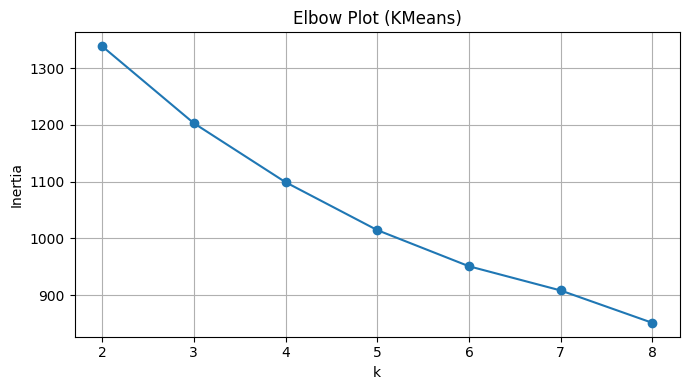

In [5]:
ks = range(2, 9)
inertias = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, marker='o')
plt.title('Elbow Plot (KMeans)')
plt.xlabel('k'); plt.ylabel('Inertia')
plt.grid(True); plt.tight_layout(); plt.show()


## 5) KMeans 학습 및 군집 부여
- 여기서는 예시로 k=3을 사용합니다(원하면 바꿔보세요).


In [6]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df['cluster'] = clusters
df[['Date','Close','cluster']].head()


Price,Date,Close,cluster
Ticker,,TSLA,
0,2025-04-28,285.880005,2
1,2025-04-29,292.029999,2
2,2025-04-30,282.160004,2
3,2025-05-01,280.519989,2
4,2025-05-02,287.209991,2


## ✅ 마지막 시각화: PCA 2D 군집 시각화 + 종가 시계열에 군집 색칠
마지막에 반드시 ‘눈으로 보이는’ 결과가 나오도록 2개 그래프를 그립니다.


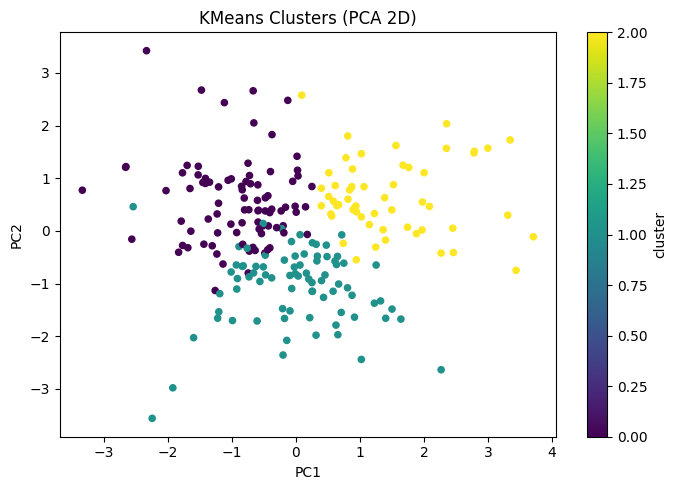

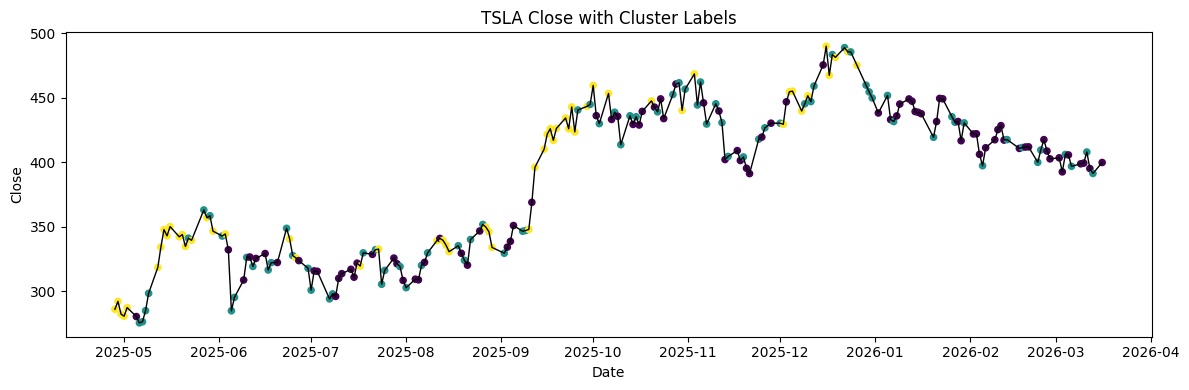

In [7]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_2d[:,0], X_2d[:,1], c=df['cluster'], s=20)
plt.title('KMeans Clusters (PCA 2D)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.colorbar(scatter, label='cluster')
plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4))
plt.plot(df['Date'], df['Close'], color='black', linewidth=1)
plt.scatter(df['Date'], df['Close'], c=df['cluster'], s=20)
plt.title('TSLA Close with Cluster Labels')
plt.xlabel('Date'); plt.ylabel('Close')
plt.tight_layout(); plt.show()


## ✅ 요약(3줄)
1) KMeans는 예측이 아니라 ‘비슷한 날들의 패턴’을 군집화해 레짐을 탐지합니다.
2) 군집은 상승/하락과 1:1로 대응하지 않을 수 있으며, 변동성/추세 상태를 나타낼 수 있습니다.
3) 군집 결과는 이후 ‘레짐별 예측 모델’을 따로 두는 방식으로 확장할 수 있습니다.
